In [3]:
import mocet
import os
import pickle
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

subject_pool = {
                'sub-003':{'ses-07R':([1,2,3,4,5], False),
                           'ses-13R':([1,2,4,5,6], False)},
                'sub-004':{'ses-07R':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-005':{'ses-07':([1,2,3,4,5,6], True)},
                'sub-006':{'ses-07R':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-008':{'ses-07R':([2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-009':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,5,6], False)},
                'sub-010':{'ses-07':([1,2,3,4,5], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-011':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-012':{'ses-07':([1,2,4,5,6], False)},
                'sub-013':{'ses-07':([1,2,3,4], False)},
                'sub-014':{'ses-07':([2,3,4,5,6], False)},
                'sub-015':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-016':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-017':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5], False)},
                'sub-018':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-020':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-021':{'ses-07':([1,2,4,5,6], False),
                           'ses-13':([1,2,4,5,6], False)},
                'sub-JJY':{'ses-07':([1,2,3,4,5,6], False)},
                'sub-KMY':{'ses-07':([1,2,3,4,5,6], False)},
                'sub-PJW':{'ses-07':([1,2,3,4,6], True)},
                'sub-PBJ':{'ses-07':([1,2,3,4,5], False)}
                }


history_onset = {'sub-003': [34.1, 26.1, 31.9, 24.9, 21.7, 18.0],
                 'sub-005': [28.66, 29.32, 28.12, 33.7, 36.1, 27.46],
                 'sub-PJW': [35, 30.8, 28.66, 26.58, None, 27.42]}
task_duration = 816

calibration_onsets = [1, 494]
calibration_points = [24, 12]
t_cal = 0

motion_param_labels = ['trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']

testable_data = pickle.load(open('../testable_data_list.pkl', 'rb'))

simulation_log_fname = f'../Figure_2/data/simulation_log.csv'
simulation_log = pd.read_csv(simulation_log_fname)
simulation_pupil_data = simulation_log[["center_x","center_y","diameter_px"]].to_numpy()

print(simulation_pupil_data.shape)
duration_tr = 510

key_simulation_pupil_data = {}
key_simulation_pupil_size = {}
k = 0
for key in testable_data.keys():
    subject = key[0]
    session = key[1]
    task = key[2]
    run = key[3]
    r = int(run[4])
    data = simulation_pupil_data[k*duration_tr:(k+1)*duration_tr,:]
    for i in range(510):
        if data[i, 0] == -1:
            data[i,:] = data[i-1,:]
    key_simulation_pupil_data[key] = data[:,:2]
    key_simulation_pupil_size[key] = data[:,2]
    k += 1


(56610, 3)


In [4]:

from numpy.polynomial.legendre import Legendre
from sklearn.linear_model import LinearRegression

def make_poly_regressors(n_samples, order=2):
    X = np.ones((n_samples, 0))
    for d in range(order):
        poly = Legendre.basis(d + 1)
        poly_trend = poly(np.linspace(-1, 1, n_samples))
        X = np.hstack((X, poly_trend[:, None]))
    return X

def polynomial_detrending(pupil_data, polynomial_order):
    X = make_poly_regressors(len(pupil_data), order=polynomial_order)
    dedrift_regressor = np.zeros((len(pupil_data), 2))
    for i in range(2):
        reg = LinearRegression().fit(X, pupil_data[:, i])
        dedrift_regressor[:, i] = reg.predict(X)
    pupil_data = pupil_data[:, :2] - dedrift_regressor
    return pupil_data

subjects = []
for key in list(testable_data.keys()):
    subjects.append(key[0])
subjects = list(set(subjects))
subjects.sort()
print(subjects)

['sub-003', 'sub-004', 'sub-005', 'sub-006', 'sub-008', 'sub-009', 'sub-010', 'sub-011', 'sub-012', 'sub-013', 'sub-014', 'sub-015', 'sub-016', 'sub-018', 'sub-020', 'sub-021', 'sub-JJY', 'sub-KMY', 'sub-PBJ', 'sub-PJW']


In [10]:
px_per_deg = 78.43
mocet_calibration_errors = {}
mocet_validation_errors = {}

for subject in subjects:
    sessions = subject_pool[subject].keys()
    for session in sessions:
        runs, history_loss = subject_pool[subject][session]
        root = f'../../_DATA/{subject}/{session}'
        for r in runs:
            run = f'run-{r}'
            np.random.seed(0)
            key = (subject, session, task, run)
            if key in testable_data.keys():
                if not mocet_calibration_errors.keys().__contains__(subject):
                    mocet_calibration_errors[subject] = []
                    mocet_validation_errors[subject] = []
                
                confounds_fname = f'{root}/{subject}_{session}_{task}_{run}_desc-confounds_timeseries.tsv'
                
                model_pupil_data = key_simulation_pupil_data[key]
                model_pupil_size = key_simulation_pupil_size[key]
            
                avg_pupil_diameter_mm = 5
                pupil_diameter_mm_per_px = avg_pupil_diameter_mm / np.nanmean(model_pupil_size)
                pupil_data_new = np.zeros_like(model_pupil_data)
                pupil_data_new[:,0] = model_pupil_data[:,0] - np.mean(model_pupil_data[:25,0])
                pupil_data_new[:,1] = model_pupil_data[:,1] - np.mean(model_pupil_data[:25,1])
                pupil_data_new = pupil_data_new * pupil_diameter_mm_per_px
            
                model_pupil_data = mocet.apply_mocet(pupil_data_new, confounds_fname, polynomial_order=3)
                
                t_cal = 0
                t_val = 1
            
                offset = calibration_onsets[t_cal]
                calibration_pupils = []
                for i in np.arange(calibration_points[t_cal]):
                    start = (offset+i)
                    calibration_pupils.append([np.nanmean(model_pupil_data[start,0]), np.nanmean(model_pupil_data[start,1])])
                calibration_pupils = np.array(calibration_pupils)
            
                repeat = True if calibration_points[t_cal]==24 else False
                calibrator = mocet.EyetrackingCalibration(repeat=repeat, method='linear')
                calibrator.fit(calibration_pupils[:, 0], calibration_pupils[:, 1])
                gaze_coordinates = calibrator.transform(model_pupil_data)
            
                for t in [t_cal, t_val]:
                    MSE = []
                    offset = calibration_onsets[t]
                    for i in np.arange(calibration_points[t]):
                        ref_x = calibrator.calibration_coordinates[calibrator.calibration_order[i]][0]
                        ref_y = calibrator.calibration_coordinates[calibrator.calibration_order[i]][1]
                        start = (offset+i)
                        data_x = np.nanmean(gaze_coordinates[start,0])
                        data_y = np.nanmean(gaze_coordinates[start,1])
                        MSE.append(np.sqrt((ref_x-data_x)**2 + (ref_y-data_y)**2))
                    if t == t_cal:
                        calibration_error = np.nanmean(MSE)/px_per_deg
                        mocet_calibration_errors[subject].append(calibration_error)
                    elif t == t_val:
                        validation_error = np.nanmean(MSE)/px_per_deg
                        mocet_validation_errors[subject].append(validation_error)
                print(key, calibration_error, validation_error)
subjects_mocet_calibration_errors = []
subjects_mocet_validation_errors = []
for key in mocet_calibration_errors.keys():
    subjects_mocet_calibration_errors.append(np.mean(mocet_calibration_errors[key], axis=0))
    subjects_mocet_validation_errors.append(np.mean(mocet_validation_errors[key], axis=0))

with open(f'data/model_mocet_calibration_error.pkl', 'wb') as f:
    pickle.dump(mocet_calibration_errors, f)
with open(f'data/model_mocet_validation_error.pkl', 'wb') as f:
    pickle.dump(mocet_validation_errors, f)
    
print(np.mean(subjects_mocet_calibration_errors), np.mean(subjects_mocet_validation_errors))

('sub-003', 'ses-07R', 'task-mcHERDING', 'run-1') 5.1003810690427544e-15 0.38986432282206596
('sub-003', 'ses-07R', 'task-mcHERDING', 'run-2') 3.7485512402519925e-15 0.39062926388080116
('sub-003', 'ses-07R', 'task-mcHERDING', 'run-3') 4.8495342980911465e-15 0.48139369443799773
('sub-003', 'ses-13R', 'task-mcHERDING', 'run-1') 3.267687246111768e-15 0.5718491091539989
('sub-003', 'ses-13R', 'task-mcHERDING', 'run-2') 3.4346175267287976e-15 0.3430136421794889
('sub-003', 'ses-13R', 'task-mcHERDING', 'run-4') 3.360143989032657e-15 0.3642471721052374
('sub-003', 'ses-13R', 'task-mcHERDING', 'run-5') 3.1610401056179666e-15 0.5425951146320658
('sub-004', 'ses-07R', 'task-mcHERDING', 'run-1') 3.1774228528977533e-15 0.45573760388597206
('sub-004', 'ses-07R', 'task-mcHERDING', 'run-2') 2.0432718598936395e-14 3.340027407747846
('sub-004', 'ses-07R', 'task-mcHERDING', 'run-4') 6.1725950379189166e-15 0.2644567864684073
('sub-004', 'ses-13', 'task-mcHERDING', 'run-1') 4.741793342841224e-15 0.271568

In [7]:
from scipy.stats import ttest_rel

px_per_deg = 78.43
for p in range(1, 13):
    polynomial_calibration_errors = {}
    polynomial_validation_errors = {}
    
    for subject in subjects:
        sessions = subject_pool[subject].keys()
        for session in sessions:
            runs, history_loss = subject_pool[subject][session]
            root = f'../../_DATA/{subject}/{session}'
            for r in runs:
                run = f'run-{r}'
                np.random.seed(0)
                key = (subject, session, task, run)
                if key in testable_data.keys():
                    if not polynomial_calibration_errors.keys().__contains__(subject):
                        polynomial_calibration_errors[subject] = []
                        polynomial_validation_errors[subject] = []
                    
                    confounds_fname = f'{root}/{subject}_{session}_{task}_{run}_desc-confounds_timeseries.tsv'
                    
                    model_pupil_data = key_simulation_pupil_data[key]
                    model_pupil_size = key_simulation_pupil_size[key]
                
                    avg_pupil_diameter_mm = 5
                    pupil_diameter_mm_per_px = avg_pupil_diameter_mm / np.nanmean(model_pupil_size)
                    pupil_data_new = np.zeros_like(model_pupil_data)
                    pupil_data_new[:,0] = model_pupil_data[:,0] - np.mean(model_pupil_data[:25,0])
                    pupil_data_new[:,1] = model_pupil_data[:,1] - np.mean(model_pupil_data[:25,1])
                    pupil_data_new = pupil_data_new * pupil_diameter_mm_per_px
                
                    model_pupil_data = polynomial_detrending(pupil_data_new, polynomial_order=p)
                    
                    t_cal = 0
                    t_val = 1
                
                    offset = calibration_onsets[t_cal]
                    calibration_pupils = []
                    for i in np.arange(calibration_points[t_cal]):
                        start = (offset+i)
                        calibration_pupils.append([np.nanmean(model_pupil_data[start,0]), np.nanmean(model_pupil_data[start,1])])
                    calibration_pupils = np.array(calibration_pupils)
                
                    repeat = True if calibration_points[t_cal]==24 else False
                    calibrator = mocet.EyetrackingCalibration(repeat=repeat, method='linear')
                    calibrator.fit(calibration_pupils[:, 0], calibration_pupils[:, 1])
                    gaze_coordinates = calibrator.transform(model_pupil_data)
                
                    for t in [t_cal, t_val]:
                        MSE = []
                        offset = calibration_onsets[t]
                        for i in np.arange(calibration_points[t]):
                            ref_x = calibrator.calibration_coordinates[calibrator.calibration_order[i]][0]
                            ref_y = calibrator.calibration_coordinates[calibrator.calibration_order[i]][1]
                            start = (offset+i)
                            data_x = np.nanmean(gaze_coordinates[start,0])
                            data_y = np.nanmean(gaze_coordinates[start,1])
                            MSE.append(np.sqrt((ref_x-data_x)**2 + (ref_y-data_y)**2))
                        if t == t_cal:
                            calibration_error = np.nanmean(MSE)/px_per_deg
                            polynomial_calibration_errors[subject].append(calibration_error)
                        elif t == t_val:
                            validation_error = np.nanmean(MSE)/px_per_deg
                            polynomial_validation_errors[subject].append(validation_error)
    with open(f'data/model_polynomial_calibration_error_p{p:02d}.pkl', 'wb') as f:
        pickle.dump(polynomial_calibration_errors, f)
    with open(f'data/model_polynomial_validation_error_p{p:02d}.pkl', 'wb') as f:
        pickle.dump(polynomial_validation_errors, f)
    
    subjects_polynomial_calibration_errors = []
    subjects_polynomial_validation_errors = []
    for key in mocet_calibration_errors.keys():
        subjects_polynomial_calibration_errors.append(np.mean(polynomial_calibration_errors[key], axis=0))
        subjects_polynomial_validation_errors.append(np.mean(polynomial_validation_errors[key], axis=0))
        
    print(p, np.mean(subjects_polynomial_calibration_errors), np.mean(subjects_polynomial_validation_errors), ttest_rel(subjects_mocet_validation_errors, subjects_polynomial_validation_errors))

1 1.9026043955260528e-14 4.144529189328317 TtestResult(statistic=-5.792991572423991, pvalue=1.3971170135570062e-05, df=19)
2 1.5171793467912173e-14 4.169009960317947 TtestResult(statistic=-5.797675898914811, pvalue=1.3831301324025529e-05, df=19)
3 7.984232048525287e-15 1.8477349621694459 TtestResult(statistic=-5.171130835222903, pvalue=5.432480684894053e-05, df=19)
4 7.970863842362304e-15 1.7670411779253876 TtestResult(statistic=-5.129865312320065, pvalue=5.953388836914959e-05, df=19)
5 8.386693362516652e-15 1.0156778242668703 TtestResult(statistic=-4.791073354497113, pvalue=0.00012699138513790523, df=19)
6 7.531258278258165e-15 1.0551541508490279 TtestResult(statistic=-4.427235895145518, pvalue=0.0002892425019109025, df=19)
7 7.351367515877309e-15 0.9966117506352493 TtestResult(statistic=-3.6106651151000655, pvalue=0.001862690200503157, df=19)
8 8.876448458984903e-15 0.9627425732362221 TtestResult(statistic=-3.907743383452983, pvalue=0.0009459311862822671, df=19)
9 8.563190793095127e-

In [9]:
uncorrected_calibration_errors = {}
uncorrected_validation_errors = {}

for subject in subjects:
    sessions = subject_pool[subject].keys()
    for session in sessions:
        runs, history_loss = subject_pool[subject][session]
        root = f'../../_DATA/{subject}/{session}'
        for r in runs:
            run = f'run-{r}'
            np.random.seed(0)
            key = (subject, session, task, run)
            if key in testable_data.keys():
                if not uncorrected_calibration_errors.keys().__contains__(subject):
                    uncorrected_calibration_errors[subject] = []
                    uncorrected_validation_errors[subject] = []
                
                confounds_fname = f'{root}/{subject}_{session}_{task}_{run}_desc-confounds_timeseries.tsv'
                
                model_pupil_data = key_simulation_pupil_data[key]
                model_pupil_size = key_simulation_pupil_size[key]
            
                model_pupil_data[:,0] = model_pupil_data[:,0] - np.mean(model_pupil_data[:,0])
                model_pupil_data[:,1] = model_pupil_data[:,1] - np.mean(model_pupil_data[:,1])
                
                t_cal = 0
                t_val = 1
            
                offset = calibration_onsets[t_cal]
                calibration_pupils = []
                for i in np.arange(calibration_points[t_cal]):
                    start = (offset+i)
                    calibration_pupils.append([np.nanmean(model_pupil_data[start,0]), np.nanmean(model_pupil_data[start,1])])
                calibration_pupils = np.array(calibration_pupils) 
                calibration_pupils += np.random.normal(0, 0.000001, calibration_pupils.shape)
            
                repeat = True if calibration_points[t_cal]==24 else False
                calibrator = mocet.EyetrackingCalibration(repeat=repeat, method='linear')
                calibrator.fit(calibration_pupils[:, 0], calibration_pupils[:, 1])
                gaze_coordinates = calibrator.transform(model_pupil_data)
            
                for t in [t_cal, t_val]:
                    MSE = []
                    offset = calibration_onsets[t]
                    for i in np.arange(calibration_points[t]):
                        ref_x = calibrator.calibration_coordinates[calibrator.calibration_order[i]][0]
                        ref_y = calibrator.calibration_coordinates[calibrator.calibration_order[i]][1]
                        start = (offset+i)
                        data_x = np.nanmean(gaze_coordinates[start,0])
                        data_y = np.nanmean(gaze_coordinates[start,1])
                        MSE.append(np.sqrt((ref_x-data_x)**2 + (ref_y-data_y)**2))
                    if t == t_cal:
                        calibration_error = np.nanmean(MSE)/px_per_deg
                        uncorrected_calibration_errors[subject].append(calibration_error)
                    elif t == t_val:
                        validation_error = np.nanmean(MSE)/px_per_deg
                        uncorrected_validation_errors[subject].append(validation_error)

subjects_uncorrected_calibration_errors = []
subjects_uncorrected_validation_errors = []
for key in mocet_calibration_errors.keys():
    subjects_uncorrected_calibration_errors.append(np.mean(uncorrected_calibration_errors[key], axis=0))
    subjects_uncorrected_validation_errors.append(np.mean(uncorrected_validation_errors[key], axis=0))
    
print(np.mean(subjects_uncorrected_calibration_errors), np.mean(subjects_uncorrected_validation_errors))

with open(f'data/model_uncorrected_calibration_error.pkl', 'wb') as f:
    pickle.dump(uncorrected_calibration_errors, f)
with open(f'data/model_uncorrected_validation_error.pkl', 'wb') as f:
    pickle.dump(uncorrected_validation_errors, f)


0.0032888937859741224 4.264205114722296


(4, 20)


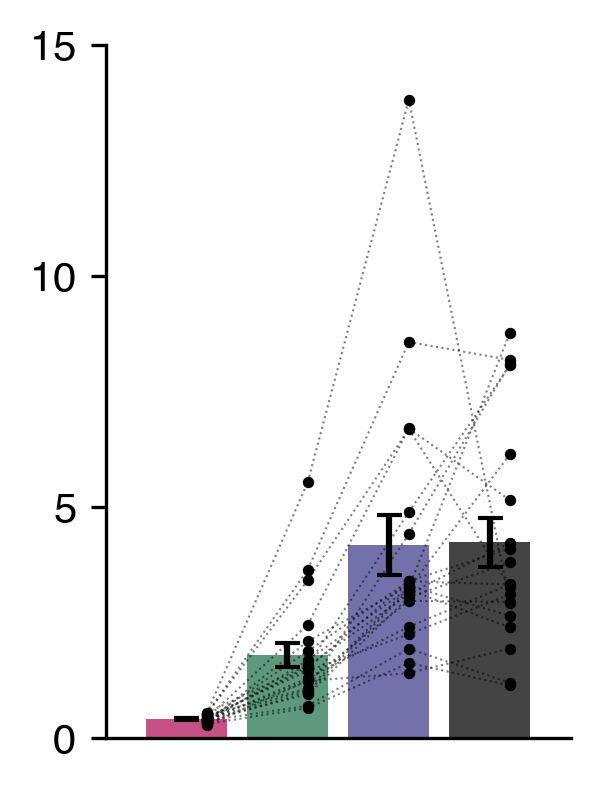

In [28]:


subjects_polynomial_validation_errors = []
for p in [1,3]:
    with open(f'data/model_polynomial_validation_error_p{p:02d}.pkl', 'rb') as f:
        polynomial_validation_errors = pickle.load(f)
    #subjects_polynomial_calibration_errors = []
    subject_polynomial_validation_errors = []
    for key in mocet_calibration_errors.keys():
        #subjects_polynomial_calibration_errors.append(np.mean(polynomial_calibration_errors[key], axis=0))
        subject_polynomial_validation_errors.append(np.mean(polynomial_validation_errors[key], axis=0))
    subjects_polynomial_validation_errors.append(subject_polynomial_validation_errors)
from scipy.stats import sem, ttest_rel, ttest_ind
plt.style.use('default')

# Define the tags for the errors
tags = ['mocet', 'polynomial', 'linear', 'uncorrected']

MSE_matrix = np.concatenate([
    np.array(subjects_mocet_validation_errors).reshape(1,-1), 
    np.flip(np.array(subjects_polynomial_validation_errors), axis=0),
    np.array(subjects_uncorrected_validation_errors).reshape(1,-1)
], axis=0)
print(MSE_matrix.shape)

#color_list = ['#c55187']+['#5e997d']*3+['#444444']
color_list = ['#c55187','#5e997d', '#7371a9', '#444444']

fig, ax = plt.subplots(1, 1, figsize=(2,3), dpi=300,  sharex=True)
ax.bar(np.arange(1+2+1),
       np.mean(MSE_matrix, axis=1),
       yerr=sem(MSE_matrix, axis=1),
       capsize=3, color=color_list)

# # Add scatter points to the box plot
for i in range(1+2+1):
    ax.scatter(np.ones(len(subjects_mocet_validation_errors)) * (i) + 0.2, MSE_matrix[i], s=3, c='k')

# Connect the scatter points
for s in range(len(subjects_mocet_validation_errors)):
    for i in range(1+2):
        ax.plot([i+0.2, i+1+0.2], [MSE_matrix[i, s], MSE_matrix[i+1, s]], c='k', linestyle=':', lw=0.5, alpha=0.5)
        

# # Set plot limits, labels, and styles
# ax.set_ylim(None, 12.5)
# #ax.set_xticks(np.arange(len(tags)))
# #ax.set_xticklabels(tags)
ax.spines[['right', 'top']].set_visible(False)
ax.set_xticks([])
ax.set_xlim(-0.8, 3.8)
ax.set_yticks([0,5,10,15])
for tick in ax.get_yticklabels():
    tick.set_fontname("Helvetica")
for tick in ax.get_xticklabels():
    tick.set_fontname("Helvetica")
# plt.subplots_adjust(wspace=0.15)
# 
# print('validation')
# print(ttest_rel(subjects_mocet_validation_errors, subjects_polynomial_validation_errors))
# print(ttest_rel(subjects_mocet_validation_errors, subjects_linear_validation_errors))
# print(ttest_rel(subjects_mocet_validation_errors, subjects_uncorrected_validation_errors))

In [30]:
print(ttest_rel(subjects_mocet_validation_errors, MSE_matrix[1]))
print(ttest_rel(subjects_mocet_validation_errors, MSE_matrix[2]))
print(ttest_rel(subjects_mocet_validation_errors, MSE_matrix[3]))

TtestResult(statistic=-5.432085856521881, pvalue=3.0567465513984416e-05, df=19)
TtestResult(statistic=-5.916422272051603, pvalue=1.0727011233096475e-05, df=19)
TtestResult(statistic=-7.303455869681834, pvalue=6.308790173208668e-07, df=19)


(14, 20)


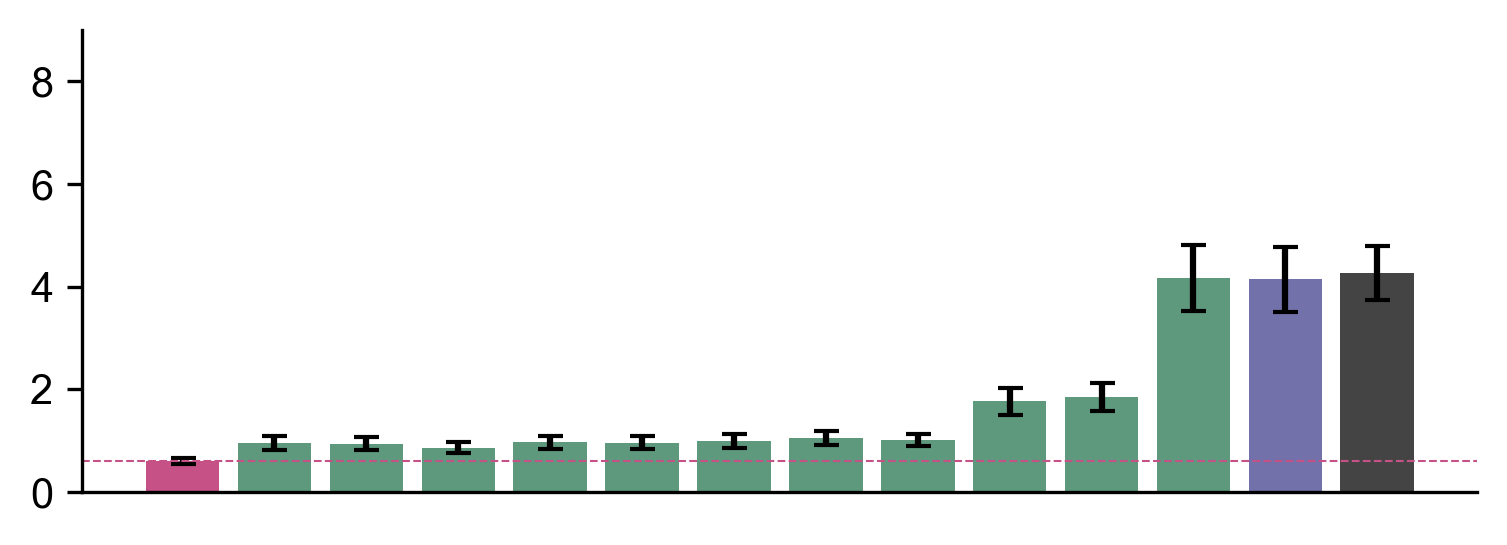

In [16]:
with open(f'data/model_mocet_validation_error.pkl', 'rb') as f:
    mocet_validation_errors = pickle.load(f)
subjects_mocet_validation_errors = []
for subject in subjects:
    subjects_mocet_validation_errors.append(np.mean(mocet_validation_errors[subject], axis=0))
    
with open(f'data/model_uncorrected_validation_error.pkl', 'rb') as f:
    uncorrected_validation_errors = pickle.load(f)
subjects_uncorrected_validation_errors = []
for subject in subjects:
    subjects_uncorrected_validation_errors.append(np.mean(uncorrected_validation_errors[subject], axis=0))
    
subjects_polynomial_validation_errors = []
for p in range(1,13):
    with open(f'data/model_polynomial_validation_error_p{p:02d}.pkl', 'rb') as f:
        polynomial_validation_errors = pickle.load(f)
    #subjects_polynomial_calibration_errors = []
    subject_polynomial_validation_errors = []
    for subject in subjects:
        #subjects_polynomial_calibration_errors.append(np.mean(polynomial_calibration_errors[key], axis=0))
        subject_polynomial_validation_errors.append(np.mean(polynomial_validation_errors[subject], axis=0))
    subjects_polynomial_validation_errors.append(subject_polynomial_validation_errors)
    
    
from scipy.stats import sem, ttest_rel, ttest_ind
plt.style.use('default')

# Define the tags for the errors
tags = ['mocet', 'polynomial', 'linear', 'uncorrected']

MSE_matrix = np.concatenate([
    np.array(subjects_mocet_validation_errors).reshape(1,-1), 
    np.flip(np.array(subjects_polynomial_validation_errors), axis=0),
    np.array(subjects_uncorrected_validation_errors).reshape(1,-1)
], axis=0)
print(MSE_matrix.shape)

color_list = ['#c55187']+['#5e997d']*11+['#7371a9', '#444444']
#color_list = ['#c55187','#5e997d', '#7371a9', '#444444']

fig, ax = plt.subplots(1, 1, figsize=(6,2), dpi=300,  sharex=True)
ax.bar(np.arange(MSE_matrix.shape[0]),
       np.mean(MSE_matrix, axis=1),
       yerr=sem(MSE_matrix, axis=1),
       capsize=3, color=color_list)

# # # Add scatter points to the box plot
# for i in range(MSE_matrix.shape[0]):
#     ax.scatter(np.ones(len(subjects_mocet_validation_errors)) * (i) + 0.2, MSE_matrix[i], s=3, c='k')
# 
# # Connect the scatter points
# for s in range(len(subjects_mocet_validation_errors)):
#     for i in range(MSE_matrix.shape[0]-1):
#         ax.plot([i+0.2, i+1+0.2], [MSE_matrix[i, s], MSE_matrix[i+1, s]], c='k', linestyle=':', lw=0.5, alpha=0.5)
#         
ax.spines[['right', 'top']].set_visible(False)
ax.set_xticks([])
ax.set_ylim(0, 9)
ax.axhline(np.mean(MSE_matrix, axis=1)[0], c='#c55187', linestyle='--', lw=0.5)
for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")
